# Laboratory 4 - Exercises


## Exercise 1: Regression Decision Tree

Use the following regression dataset:

```python
X = np.random.rand(350,1)
y = (X + 1.2)^3 - 10 + np.random.randn(350,1)/10
```

Build a regression decision tree with `max_depth=3` and `min_samples_leaf=5`. Visualize the trained decision tree and plot the regression predictions.


In [107]:
from sklearn.tree import DecisionTreeRegressor
import numpy as np
import matplotlib.pyplot as plt

X = np.random.rand(350, 1)
y = (X + 1.2) ** 3 - 10 + np.random.randn(350, 1) / 10

tree_reg = DecisionTreeRegressor(max_depth=3, min_samples_leaf=5, random_state=42)
tree_reg.fit(X, y)

DecisionTreeRegressor(max_depth=3, min_samples_leaf=5, random_state=42)

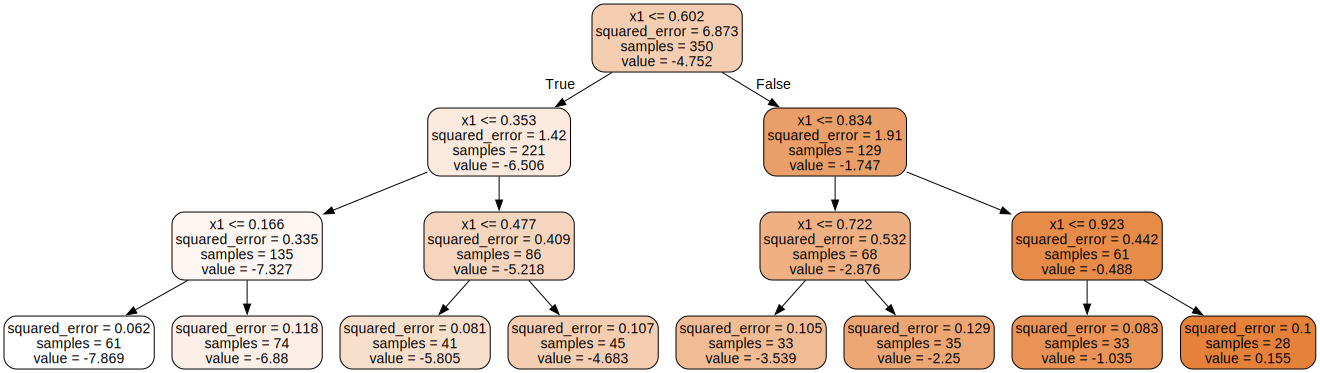

In [108]:
import os
from graphviz import Source
from sklearn.tree import export_graphviz

export_graphviz(
    tree_reg,
    out_file=os.path.join(".", "regression_tree.dot"),
    feature_names=["x1"],
    rounded=True,
    filled=True,
)

Source.from_file(os.path.join(".", "regression_tree.dot"))

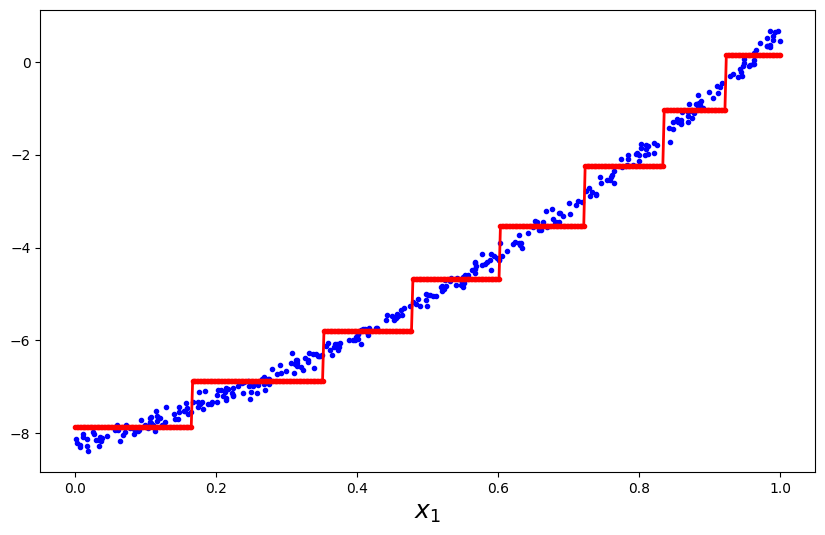

In [109]:
def plot_regression_predictions(tree_reg, X, y, axes=[0, 1, -0.2, 1], ylabel="$y$"):
    x1 = np.linspace(axes[0], axes[1], 500).reshape(-1, 1)
    y_pred = tree_reg.predict(x1)
    plt.figure(figsize=(10, 6))
    plt.plot(X, y, "b.")
    plt.plot(x1, y_pred, "r.-", linewidth=2, label=r"$\hat{y}$")
    plt.xlabel("$x_1$", fontsize=18)


plot_regression_predictions(tree_reg, X, y)

## Exercise 2: Bagging Classification

Use the `digits` dataset to perform a classification task using bagging. Set the number of estimators to 200. The test split should be 15% of the initial dataset. Print the accuracy of the model.


In [110]:
from sklearn.ensemble import BaggingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_digits

digits_dataset = load_digits()
X_train, X_test, y_train, y_test = train_test_split(
    digits_dataset["data"], digits_dataset["target"], test_size=0.15, random_state=42
)

X = digits_dataset.data
y = digits_dataset.target

bag_clf = BaggingClassifier(
    DecisionTreeClassifier(),
    n_estimators=200,
    max_samples=100,
    bootstrap=True,
    random_state=42,
)
bag_clf.fit(X_train, y_train)
y_pred = bag_clf.predict(X_test)

In [111]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred))

0.9222222222222223


In [112]:
tree_clf = DecisionTreeClassifier(random_state=42)
tree_clf.fit(X_train, y_train)
y_pred_tree = tree_clf.predict(X_test)
print(accuracy_score(y_test, y_pred_tree))

0.8555555555555555


## Exercise 3: Gradient Boosting Regression

Use the following regression dataset:

```python
X = np.random.rand(160,1) - 1
y = 2*(X[:, 0])^2 + 0.2*np.random.randn(160)
```

Perform gradient boosting using the `GradientBoostingRegressor` class with hyperparameters: `max_depth=2` and `n_estimators=100`. The test split is 25% of the initial dataset. Use early stopping to find the optimal number of trees and plot:

- the model's predictions with 100 estimators
- the model's predictions with the optimal number of trees


In [113]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error

X = np.random.rand(160, 1) - 1
y = 2 * (X[:, 0]) ** 2 + 0.2 * np.random.randn(160)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, random_state=42, test_size=0.25
)

In [114]:
gbrt = GradientBoostingRegressor(max_depth=2, n_estimators=100, random_state=42)
gbrt.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=2, random_state=42)

In [115]:
errors = [mean_squared_error(y_test, y_pred) for y_pred in gbrt.staged_predict(X_test)]

bst_n_estimators = np.argmin(errors) + 1

In [116]:
gbrt_best = GradientBoostingRegressor(
    max_depth=2, n_estimators=bst_n_estimators, random_state=42
)
gbrt_best.fit(X_train, y_train)

GradientBoostingRegressor(max_depth=2, n_estimators=47, random_state=42)

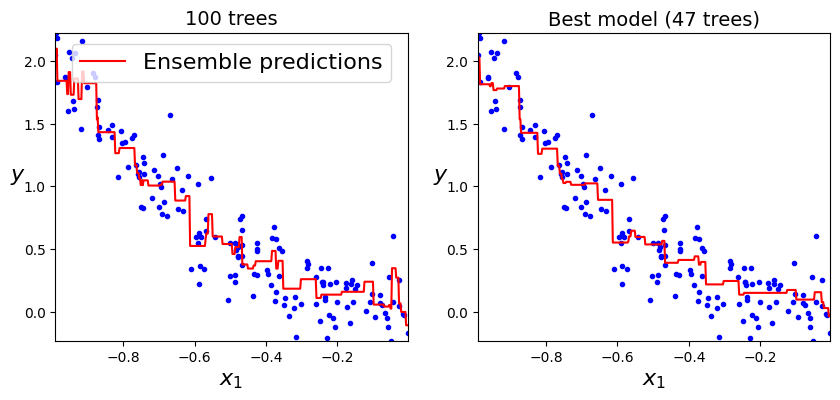

In [117]:
def plot_predictions(
    regressors, X, y, axes, label=None, style="r-", data_style="b.", data_label=None
):
    x1 = np.linspace(axes[0], axes[1], 500)
    y_pred = sum(regressor.predict(x1.reshape(-1, 1)) for regressor in regressors)
    plt.plot(X[:, 0], y, data_style, label=data_label)
    plt.plot(x1, y_pred, style, label=label)
    if label or data_label:
        plt.legend(loc="upper center", fontsize=16)

    plt.axis(axes)


plt.figure(figsize=(10, 4))
plt.subplot(121)
plot_predictions(
    [gbrt],
    X,
    y,
    axes=[X[:, 0].min(), X[:, 0].max(), y.min(), y.max()],
    label="Ensemble predictions",
)
plt.title("100 trees", fontsize=14)
plt.xlabel("$x_1$", fontsize=16)
plt.ylabel("$y$", fontsize=16, rotation=0)

plt.subplot(122)
plot_predictions(
    [gbrt_best], X, y, axes=[X[:, 0].min(), X[:, 0].max(), y.min(), y.max()]
)
plt.title("Best model (%d trees)" % bst_n_estimators, fontsize=14)

plt.ylabel("$y$", fontsize=16, rotation=0)
plt.xlabel("$x_1$", fontsize=16)

plt.show()